In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
# https://www.kaggle.com/datasets/tamber/steam-video-games
dataset = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/steam-200k.csv',
    header=None,
    names=['user-id', 'game-title', 'behavior-name', 'value', 'timestamp'],
)
dataset

,user-id,game-title,behavior-name,value,timestamp
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
...,...,...,...,...,...
199995,128470551,Titan Souls,play,1.5,0
199996,128470551,Grand Theft Auto Vice City,purchase,1.0,0
199997,128470551,Grand Theft Auto Vice City,play,1.5,0
199998,128470551,RUSH,purchase,1.0,0


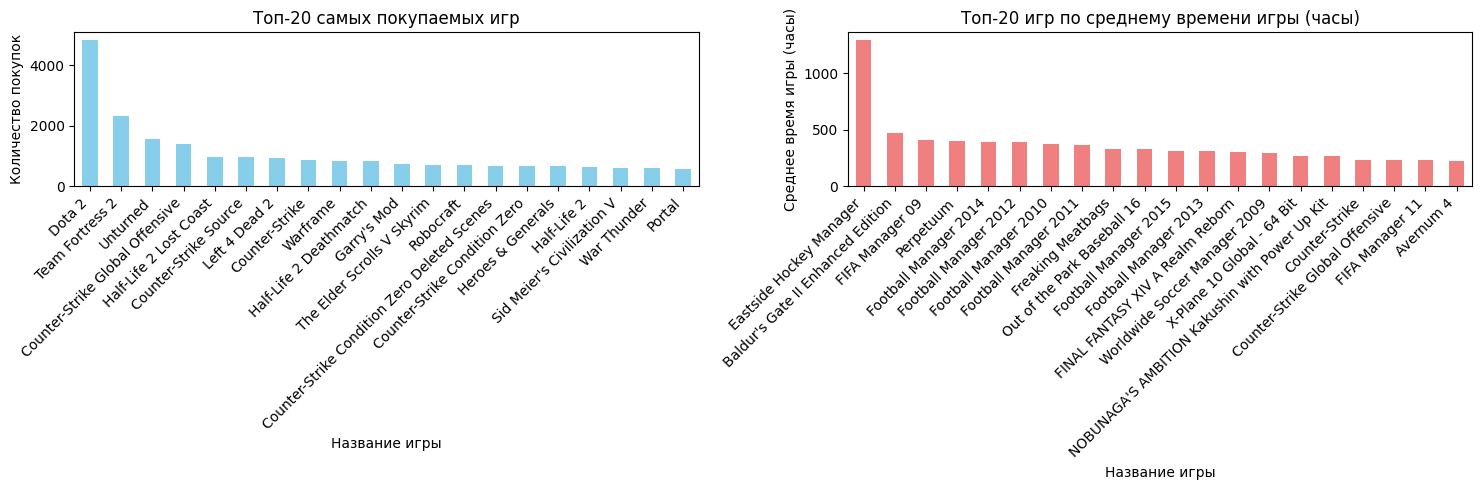

In [3]:
import matplotlib.pyplot as plt

# Анализ данных о играх и времени
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
purchase_counts = dataset[dataset['behavior-name'] == 'purchase'].groupby('game-title').size().sort_values(ascending=False)
purchase_counts.head(20).plot(kind='bar', color='skyblue')
plt.title('Топ-20 самых покупаемых игр')
plt.xlabel('Название игры')
plt.ylabel('Количество покупок')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
play_data = dataset[dataset['behavior-name'] == 'play']
play_time = play_data.groupby('game-title')['value'].mean().sort_values(ascending=False)
play_time.head(20).plot(kind='bar', color='lightcoral')
plt.title('Топ-20 игр по среднему времени игры (часы)')
plt.xlabel('Название игры')
plt.ylabel('Среднее время игры (часы)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [58]:
# Создание матрицы рейтингов
play_data = dataset[dataset['behavior-name'] == 'play'].copy()

# Вычисляем среднее время игры для каждого пользователя
user_avg_play_time = play_data.groupby('user-id')['value'].mean().reset_index()
user_avg_play_time.columns = ['user-id', 'avg_play_time']

# Объединяем с исходными данными
play_data = play_data.merge(user_avg_play_time, on='user-id')

# Вычисляем нормализованный рейтинг
play_data['normalized_rating'] = play_data['value'] / play_data['avg_play_time']

quantiles = play_data['normalized_rating'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

print("Квантили нормализованных рейтингов:")
for q, value in quantiles.items():
    print(f"{int(q*100)}%: {value:.3f}")

# Функция преобразования в рейтинг на основе квантилей
def normalized_to_rating_quantile(normalized_value):
    for q in range(1,10):
      if normalized_value <= quantiles[q/10]:
          return q
    return 10

play_data['rating'] = play_data['normalized_rating'].apply(normalized_to_rating_quantile)

# Создание матрицы пользователь-игра
user_game_matrix = play_data.pivot_table(
    index='user-id',
    columns='game-title',
    values='rating',
    aggfunc='mean'
).fillna(0)

print(f"Размер матрицы пользователь-игра: {user_game_matrix.shape}")
print(f"Количество пользователей: {user_game_matrix.shape[0]}")
print(f"Количество игр: {user_game_matrix.shape[1]}")
print(f"Заполненность матрицы: {(user_game_matrix > 0).sum().sum() / (user_game_matrix.shape[0] * user_game_matrix.shape[1]) * 100:.2f}%")

Квантили нормализованных рейтингов:
10%: 0.016
20%: 0.042
30%: 0.088
40%: 0.168
50%: 0.303
60%: 0.549
70%: 1.000
80%: 1.086
90%: 2.186
Размер матрицы пользователь-игра: (11350, 3600)
Количество пользователей: 11350
Количество игр: 3600
Заполненность матрицы: 0.17%


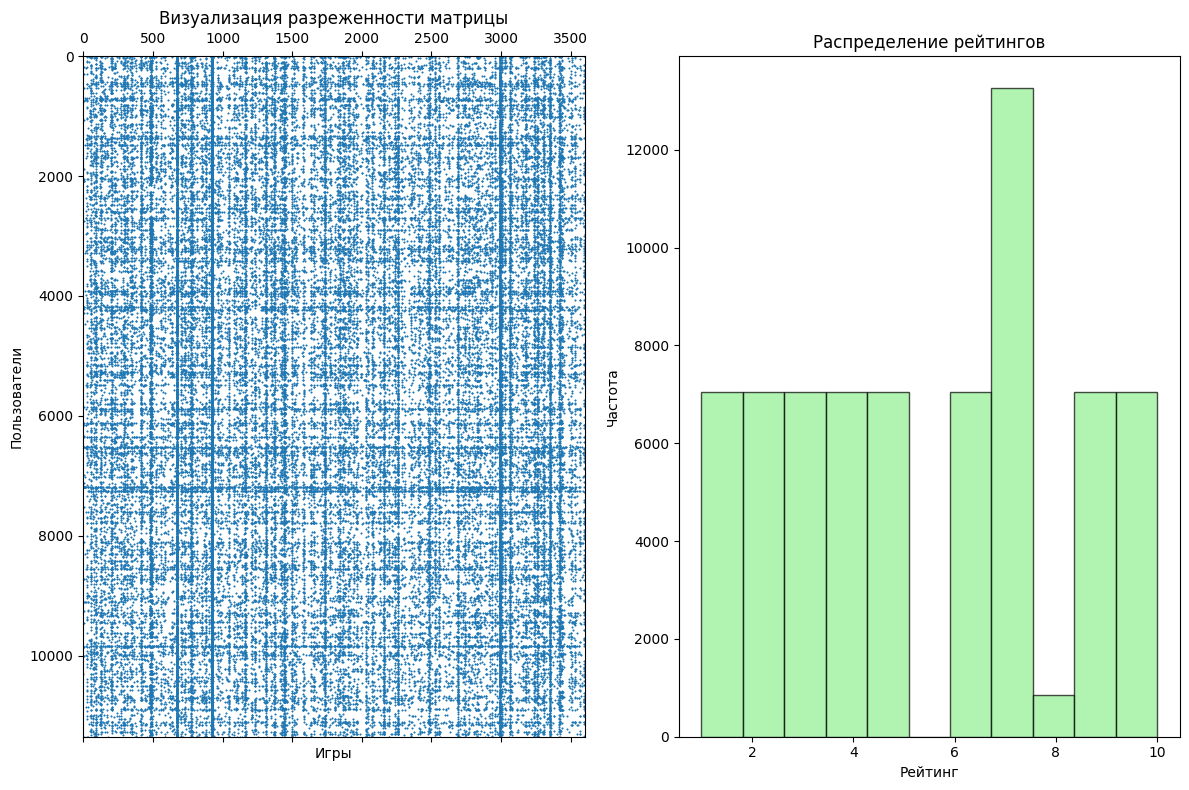

In [68]:
# Визуализация разреженности матрицы
plt.figure(figsize=(12, 8))

# Случайная выборка для визуализации
sample_users = user_game_matrix.sample(n=user_game_matrix.shape[0], axis=0)
sample_games = sample_users.sample(n=user_game_matrix.shape[1], axis=1)

plt.subplot(1, 2, 1)
plt.spy(sample_users.values, markersize=0.5, aspect='auto')
plt.title('Визуализация разреженности матрицы')
plt.xlabel('Игры')
plt.ylabel('Пользователи')

plt.subplot(1, 2, 2)
ratings_dist = user_game_matrix[user_game_matrix > 0].values.flatten()
plt.hist(ratings_dist, bins=11, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [73]:
import numpy as np

# Реализация различных мер близости
def cosine_similarity(user1_ratings, user2_ratings):
    """Косинусная мера близости"""
    mask = (user1_ratings > 0) & (user2_ratings > 0)
    if not mask.any():
        return 0

    dot_product = np.dot(user1_ratings[mask], user2_ratings[mask])
    norm1 = np.linalg.norm(user1_ratings[mask])
    norm2 = np.linalg.norm(user2_ratings[mask])

    if norm1 == 0 or norm2 == 0:
        return 0
    return dot_product / (norm1 * norm2)

def pearson_similarity(user1_ratings, user2_ratings):
    """Корреляция Пирсона"""
    mask = (user1_ratings > 0) & (user2_ratings > 0)
    if not mask.any() or np.sum(mask) < 2:
        return 0

    common_ratings1 = user1_ratings[mask]
    common_ratings2 = user2_ratings[mask]

    mean1 = np.mean(common_ratings1)
    mean2 = np.mean(common_ratings2)

    numerator = np.sum((common_ratings1 - mean1) * (common_ratings2 - mean2))
    denominator = np.sqrt(np.sum((common_ratings1 - mean1)**2)) * np.sqrt(np.sum((common_ratings2 - mean2)**2))

    if denominator == 0:
        return 0
    return numerator / denominator

def adjusted_cosine_similarity(user1_ratings, user2_ratings, item_means):
    """Скорректированная косинусная мера (учитывает средние по играм)"""
    mask = (user1_ratings > 0) & (user2_ratings > 0)
    if not mask.any():
        return 0

    adjusted_ratings1 = user1_ratings[mask] - item_means[mask]
    adjusted_ratings2 = user2_ratings[mask] - item_means[mask]

    dot_product = np.dot(adjusted_ratings1, adjusted_ratings2)
    norm1 = np.linalg.norm(adjusted_ratings1)
    norm2 = np.linalg.norm(adjusted_ratings2)

    if norm1 == 0 or norm2 == 0:
        return 0
    return dot_product / (norm1 * norm2)

# Вычисление средних рейтингов по играм
item_means = user_game_matrix.replace(0, np.nan).mean(axis=0).fillna(0).values

In [74]:
def find_similar_users(target_user_id, user_game_matrix, similarity_measure='cosine', k=10):
    """Поиск K наиболее похожих пользователей"""
    target_ratings = user_game_matrix.loc[target_user_id].values
    similarities = []

    for user_id in user_game_matrix.index:
        if user_id == target_user_id:
            continue

        user_ratings = user_game_matrix.loc[user_id].values

        if similarity_measure == 'cosine':
            similarity = cosine_similarity(target_ratings, user_ratings)
        elif similarity_measure == 'pearson':
            similarity = pearson_similarity(target_ratings, user_ratings)
        elif similarity_measure == 'adjusted_cosine':
            similarity = adjusted_cosine_similarity(target_ratings, user_ratings, item_means)
        else:
            similarity = cosine_similarity(target_ratings, user_ratings)

        if similarity > 0:  # Учитываем только положительные сходства
            similarities.append((user_id, similarity))

    # Сортируем по убыванию сходства и возвращаем топ-K
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

# Тестирование на конкретном пользователе
test_user = user_game_matrix.index[0]
similar_users_cosine = find_similar_users(test_user, user_game_matrix, 'cosine', 5)
similar_users_pearson = find_similar_users(test_user, user_game_matrix, 'pearson', 5)
similar_users_adj = find_similar_users(test_user, user_game_matrix, 'adjusted_cosine', 5)

print(f"Топ-5 похожих пользователей для пользователя {test_user}:")
print("Косинусная мера:", [f"{user}({sim:.3f})" for user, sim in similar_users_cosine])
print("Корреляция Пирсона:", [f"{user}({sim:.3f})" for user, sim in similar_users_pearson])
print("Скорректированная косинусная:", [f"{user}({sim:.3f})" for user, sim in similar_users_adj])

Топ-5 похожих пользователей для пользователя 5250:
Косинусная мера: ['50229934(1.000)', '229911(1.000)', '622362(1.000)', '994489(1.000)', '1364546(1.000)']
Корреляция Пирсона: ['56038151(1.000)', '77127388(1.000)', '77830706(1.000)', '123101539(1.000)', '135012938(1.000)']
Скорректированная косинусная: ['50229934(1.000)', '229911(1.000)', '994489(1.000)', '1364546(1.000)', '2083767(1.000)']


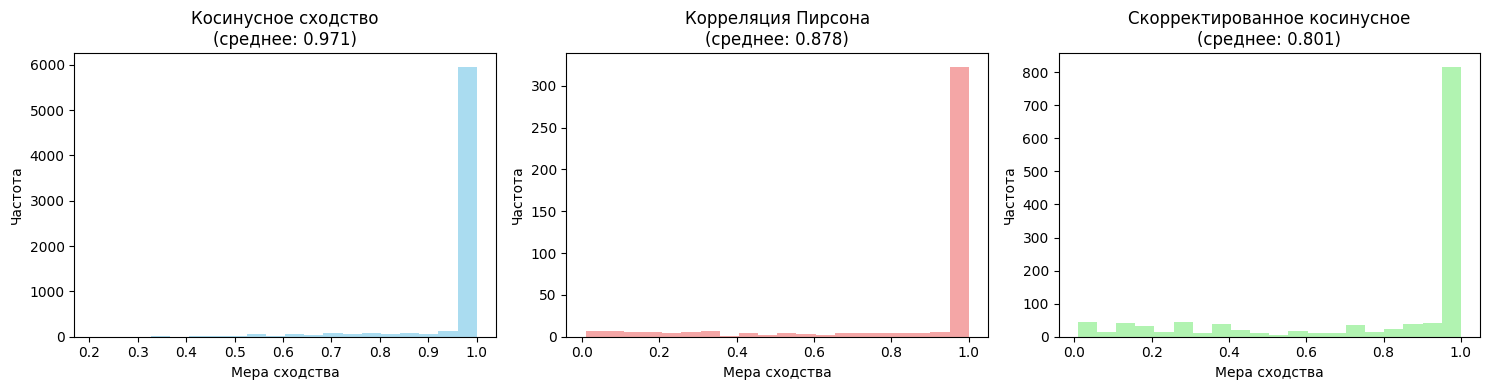

In [75]:
# Визуализация распределения сходств для разных мер
def plot_similarity_distribution(target_user_id, user_game_matrix):
    """Визуализация распределения мер сходства"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    measures = ['cosine', 'pearson', 'adjusted_cosine']
    titles = ['Косинусное сходство', 'Корреляция Пирсона', 'Скорректированное косинусное']

    for i, (measure, title) in enumerate(zip(measures, titles)):
        similarities = []
        target_ratings = user_game_matrix.loc[target_user_id].values

        for user_id in user_game_matrix.index:  # [:1000] Ограничиваем выборку для скорости
            if user_id == target_user_id:
                continue

            user_ratings = user_game_matrix.loc[user_id].values
            if measure == 'cosine':
                sim = cosine_similarity(target_ratings, user_ratings)
            elif measure == 'pearson':
                sim = pearson_similarity(target_ratings, user_ratings)
            else:
                sim = adjusted_cosine_similarity(target_ratings, user_ratings, item_means)

            if sim > 0:
                similarities.append(sim)

        axes[i].hist(similarities, bins=20, alpha=0.7, color=['skyblue', 'lightcoral', 'lightgreen'][i])
        axes[i].set_title(f'{title}\n(среднее: {np.mean(similarities):.3f})')
        axes[i].set_xlabel('Мера сходства')
        axes[i].set_ylabel('Частота')

    plt.tight_layout()
    plt.show()

plot_similarity_distribution(test_user, user_game_matrix)

In [76]:
def predict_ratings(target_user_id, user_game_matrix, similarity_measure='cosine', k=10):
    """Предсказание рейтингов для целевого пользователя"""
    similar_users = find_similar_users(target_user_id, user_game_matrix, similarity_measure, k)
    target_ratings = user_game_matrix.loc[target_user_id].values
    predicted_ratings = np.zeros_like(target_ratings)

    for game_idx in range(len(target_ratings)):
        if target_ratings[game_idx] > 0:  # Пропускаем уже оцененные игры
            predicted_ratings[game_idx] = target_ratings[game_idx]
            continue

        numerator = 0
        denominator = 0

        for similar_user_id, similarity in similar_users:
            similar_user_ratings = user_game_matrix.loc[similar_user_id].values

            if similar_user_ratings[game_idx] > 0:
                numerator += similarity * similar_user_ratings[game_idx]
                denominator += abs(similarity)

        if denominator > 0:
            predicted_ratings[game_idx] = numerator / denominator
        else:
            predicted_ratings[game_idx] = 0

    return predicted_ratings

# Предсказание для тестового пользователя
predicted_cosine = predict_ratings(test_user, user_game_matrix, 'cosine')
predicted_pearson = predict_ratings(test_user, user_game_matrix, 'pearson')
predicted_adj = predict_ratings(test_user, user_game_matrix, 'adjusted_cosine')

print("Пример предсказанных рейтингов для первых 10 игр:")
print("Исходные:", user_game_matrix.loc[test_user].values[:500])
print("Косинусные:", predicted_cosine[:500].round(2))
print("Пирсон:", predicted_pearson[:500].round(2))
print("Скорректированные:", predicted_adj[:500].round(2))

Пример предсказанных рейтингов для первых 10 игр:
Исходные: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import random

# Функция для разделения данных на train/test
def train_test_split_user_based(user_game_matrix, test_size=0.2, random_state=42):
    """Разделение данных по пользователям с сохранением непересекающихся множеств игр"""
    train_matrix = user_game_matrix.copy()
    test_matrix = user_game_matrix.copy()

    # Для каждого пользователя случайно выбираем игры для теста
    for user_id in user_game_matrix.index:
        user_ratings = user_game_matrix.loc[user_id]
        rated_games = user_ratings[user_ratings > 0].index.tolist()

        if len(rated_games) > 1:
            test_games = random.sample(rated_games, max(1, int(len(rated_games) * test_size)))

            # В тренировочной матрице зануляем тестовые игры
            train_matrix.loc[user_id, test_games] = 0
            # В тестовой матрице оставляем только тестовые игры
            test_matrix.loc[user_id, :] = 0
            test_matrix.loc[user_id, test_games] = user_game_matrix.loc[user_id, test_games]

    return train_matrix, test_matrix

# Разделение данных
train_matrix, test_matrix = train_test_split_user_based(user_game_matrix, test_size=0.2)
print(f"Train matrix shape: {train_matrix.shape}")
print(f"Test matrix shape: {test_matrix.shape}")
print(f"Train non-zero: {(train_matrix > 0).sum().sum()}")
print(f"Test non-zero: {(test_matrix > 0).sum().sum()}")

Train matrix shape: (11350, 3600)
Test matrix shape: (11350, 3600)
Train non-zero: 57395
Test non-zero: 19641


In [78]:
# Модифицированная функция предсказания для работы с train матрицей
def predict_ratings_with_train(target_user_id, train_matrix, similarity_measure='cosine', k=10):
    """Предсказание рейтингов на основе тренировочной матрицы"""
    similar_users = find_similar_users(target_user_id, train_matrix, similarity_measure, k)
    target_ratings = train_matrix.loc[target_user_id].values
    predicted_ratings = np.zeros_like(target_ratings)

    for game_idx in range(len(target_ratings)):
        # Предсказываем только для игр, которых нет в тренировочном наборе
        if target_ratings[game_idx] == 0:
            numerator = 0
            denominator = 0

            for similar_user_id, similarity in similar_users:
                similar_user_ratings = train_matrix.loc[similar_user_id].values

                if similar_user_ratings[game_idx] > 0:
                    numerator += similarity * similar_user_ratings[game_idx]
                    denominator += abs(similarity)

            if denominator > 0:
                predicted_ratings[game_idx] = numerator / denominator

    return predicted_ratings

In [79]:
def precision_at_k(predictions, actual, k=10, threshold=3):
    """Precision@K - доля релевантных рекомендаций в топ-K"""
    # Получаем топ-K предсказанных игр
    top_k_pred = predictions.nlargest(k).index

    # Получаем релевантные игры (с рейтингом выше порога)
    relevant_actual = actual[actual >= threshold].index

    # Вычисляем precision
    relevant_in_top_k = len(set(top_k_pred) & set(relevant_actual))
    return relevant_in_top_k / k

def recall_at_k(predictions, actual, k=10, threshold=3):
    """Recall@K - доля найденных релевантных игр в топ-K"""
    top_k_pred = predictions.nlargest(k).index
    relevant_actual = actual[actual >= threshold].index

    if len(relevant_actual) == 0:
        return 0

    relevant_in_top_k = len(set(top_k_pred) & set(relevant_actual))
    return relevant_in_top_k / len(relevant_actual)

def ndcg_at_k(predictions, actual, k=10):
    """Normalized Discounted Cumulative Gain @ K"""
    # Сортируем предсказания и фактические значения
    top_k_pred = predictions.nlargest(k).index
    actual_sorted = actual.loc[top_k_pred].sort_values(ascending=False)

    # Вычисляем DCG
    dcg = 0
    for i, (game, rating) in enumerate(actual_sorted.items(), 1):
        if i == 1:
            dcg += rating
        else:
            dcg += rating / np.log2(i + 1)

    # Вычисляем идеальный DCG
    ideal_actual = actual.nlargest(k)
    idcg = 0
    for i, (game, rating) in enumerate(ideal_actual.items(), 1):
        if i == 1:
            idcg += rating
        else:
            idcg += rating / np.log2(i + 1)

    return dcg / idcg if idcg > 0 else 0

def map_at_k(predictions, actual, k=10, threshold=3):
    """Mean Average Precision @ K"""
    top_k_pred = predictions.nlargest(k).index
    relevant_actual = actual[actual >= threshold].index

    average_precision = 0
    num_relevant = 0

    for i, game in enumerate(top_k_pred, 1):
        if game in relevant_actual:
            num_relevant += 1
            average_precision += num_relevant / i

    return average_precision / min(k, len(relevant_actual)) if min(k, len(relevant_actual)) > 0 else 0

In [80]:
def evaluate_recommendation_quality(train_matrix, test_matrix, similarity_measures, k_values=[5, 10, 20]):
    """Комплексная оценка качества рекомендаций с различными метриками"""
    results = {}

    # Выбираем пользователей с достаточным количеством тестовых данных
    users_with_test_data = test_matrix[(test_matrix > 0).sum(axis=1) >= 3].index
    print(f"users_with_test_data: {len(users_with_test_data)}")

    for measure in similarity_measures:
        print(f"Оценка для меры {measure}...")
        measure_results = {}

        for k in k_values:
            precisions = []
            recalls = []
            ndcgs = []
            maps = []

            for user_id in users_with_test_data[:10]:  # Ограничиваем для скорости
                try:
                    # Предсказываем рейтинги
                    predicted_ratings = predict_ratings_with_train(user_id, train_matrix, measure)
                    predicted_series = pd.Series(predicted_ratings, index=train_matrix.columns)
                    actual_series = test_matrix.loc[user_id]

                    # Вычисляем метрики
                    precisions.append(precision_at_k(predicted_series, actual_series, k))
                    recalls.append(recall_at_k(predicted_series, actual_series, k))
                    ndcgs.append(ndcg_at_k(predicted_series, actual_series, k))
                    maps.append(map_at_k(predicted_series, actual_series, k))

                except Exception as e:
                    continue

            measure_results[f'P@{k}'] = np.mean(precisions) if precisions else 0
            measure_results[f'R@{k}'] = np.mean(recalls) if recalls else 0
            measure_results[f'NDCG@{k}'] = np.mean(ndcgs) if ndcgs else 0
            measure_results[f'MAP@{k}'] = np.mean(maps) if maps else 0

        results[measure] = measure_results

    return results

# Запуск комплексной оценки
similarity_measures = ['cosine', 'pearson', 'adjusted_cosine']
quality_results = evaluate_recommendation_quality(train_matrix, test_matrix, similarity_measures)

print("\nРезультаты оценки качества рекомендаций:")
for measure, metrics in quality_results.items():
    print(f"\n{measure.upper()}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

users_with_test_data: 1069
Оценка для меры cosine...
Оценка для меры pearson...
Оценка для меры adjusted_cosine...

Результаты оценки качества рекомендаций:

COSINE:
  P@5: 0.0400
  R@5: 0.0183
  NDCG@5: 0.0774
  MAP@5: 0.0100
  P@10: 0.0400
  R@10: 0.0723
  NDCG@10: 0.1129
  MAP@10: 0.0177
  P@20: 0.0300
  R@20: 0.1390
  NDCG@20: 0.1824
  MAP@20: 0.0194

PEARSON:
  P@5: 0.0400
  R@5: 0.0067
  NDCG@5: 0.0553
  MAP@5: 0.0180
  P@10: 0.0400
  R@10: 0.0243
  NDCG@10: 0.0883
  MAP@10: 0.0154
  P@20: 0.0450
  R@20: 0.0916
  NDCG@20: 0.1994
  MAP@20: 0.0150

ADJUSTED_COSINE:
  P@5: 0.0800
  R@5: 0.0466
  NDCG@5: 0.1214
  MAP@5: 0.0405
  P@10: 0.0600
  R@10: 0.0866
  NDCG@10: 0.1539
  MAP@10: 0.0318
  P@20: 0.0400
  R@20: 0.1400
  NDCG@20: 0.1901
  MAP@20: 0.0296


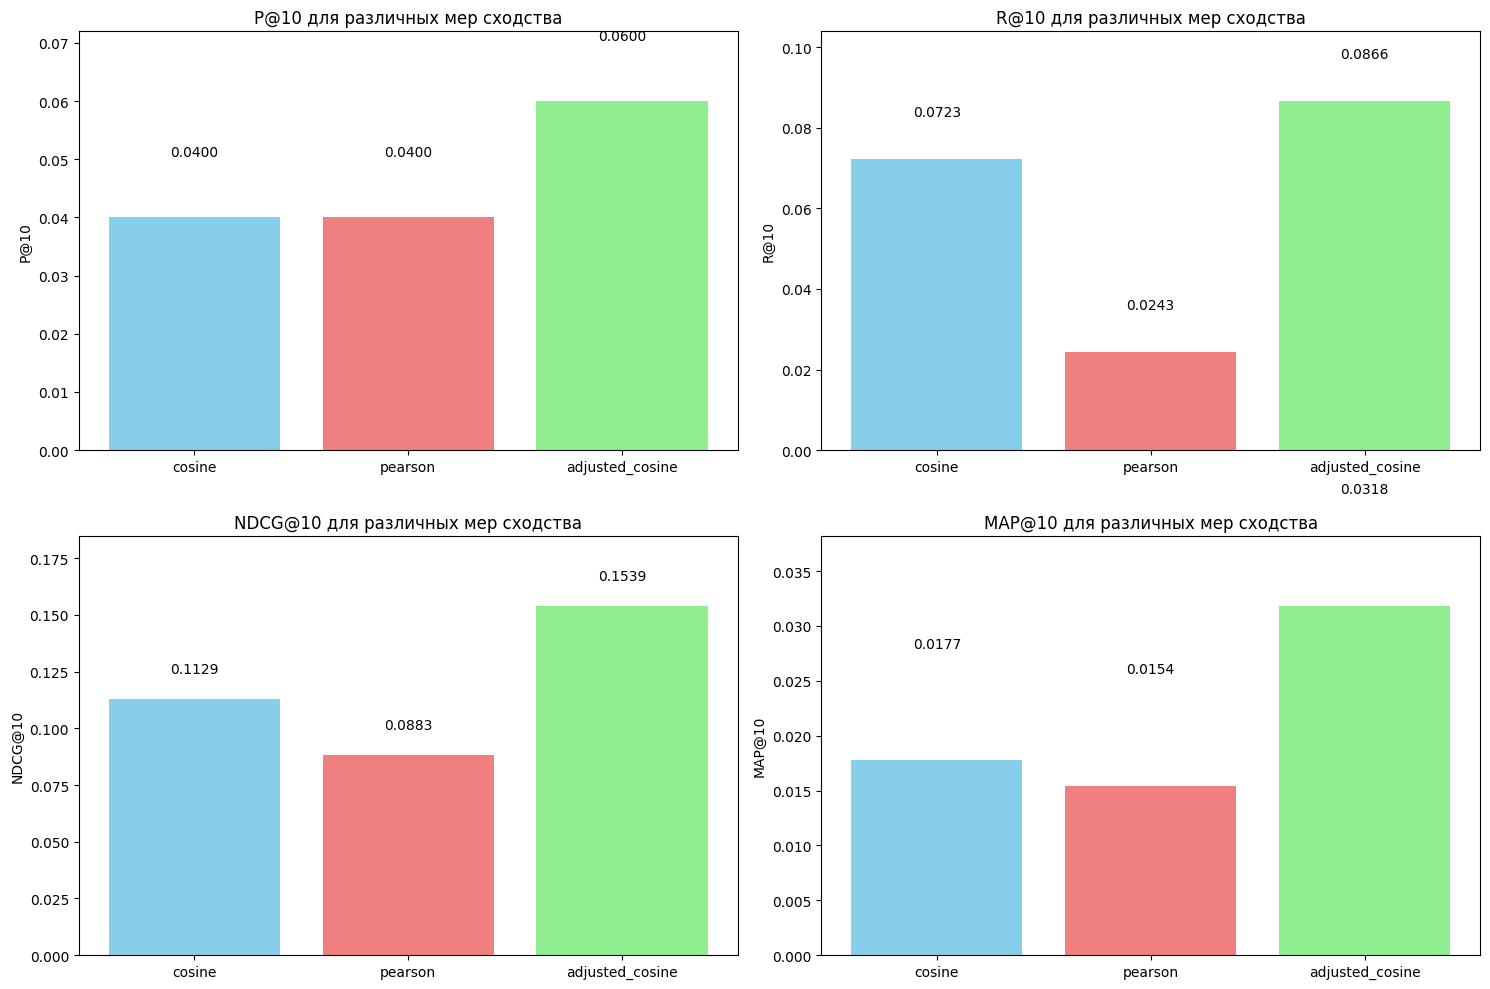

In [81]:
# Визуализация результатов оценки качества
metrics_to_plot = ['P@10', 'R@10', 'NDCG@10', 'MAP@10']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    values = [quality_results[measure][metric] for measure in similarity_measures]
    bars = axes[i].bar(similarity_measures, values, color=['skyblue', 'lightcoral', 'lightgreen'])
    axes[i].set_title(f'{metric} для различных мер сходства')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, max(values) * 1.2)

    # Добавляем значения на столбцы
    for bar, value in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Вычисление ROC-AUC для cosine...
Вычисление ROC-AUC для pearson...
Вычисление ROC-AUC для adjusted_cosine...

ROC-AUC результаты:
cosine: 0.5183
pearson: 0.5453
adjusted_cosine: 0.5003


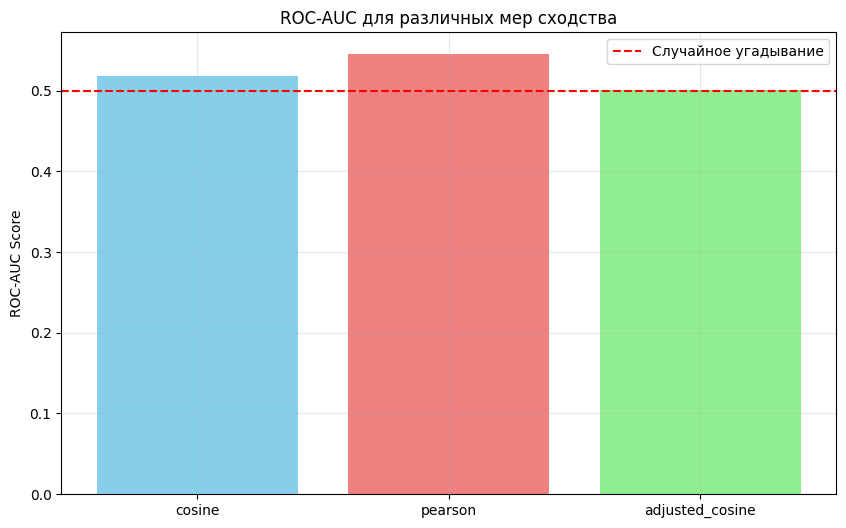

In [ ]:
def evaluate_roc_auc(train_matrix, test_matrix, similarity_measures):
    """Оценка с использованием ROC-AUC"""
    roc_results = {}

    users_with_test_data = test_matrix[(test_matrix > 0).sum(axis=1) >= 5].index

    for measure in similarity_measures:
        print(f"Вычисление ROC-AUC для {measure}...")
        all_y_true = []
        all_y_pred = []

        for user_id in users_with_test_data[:10]:  # Ограничиваем для скорости
            try:
                predicted_ratings = predict_ratings_with_train(user_id, train_matrix, measure)
                actual_ratings = test_matrix.loc[user_id].values

                # Бинаризуем: 1 если рейтинг >= 3, иначе 0
                y_true = (actual_ratings >= 3).astype(int)
                y_pred = (predicted_ratings >= 3).astype(int)

                # Учитываем только те позиции, где есть тестовые данные
                mask = actual_ratings > 0

                if np.sum(y_true[mask]) > 0 and np.sum(y_true[mask]) < len(y_true[mask]):
                    all_y_true.extend(y_true[mask])
                    all_y_pred.extend(y_pred[mask])

            except Exception as e:
                continue

        if all_y_true and len(np.unique(all_y_true)) > 1:
            roc_auc = roc_auc_score(all_y_true, all_y_pred)
            roc_results[measure] = roc_auc
        else:
            roc_results[measure] = 0.5  # Случайное угадывание

    return roc_results

# Оценка ROC-AUC
roc_results = evaluate_roc_auc(train_matrix, test_matrix, similarity_measures)

print("\nROC-AUC результаты:")
for measure, auc_score in roc_results.items():
    print(f"{measure}: {auc_score:.4f}")

# Визуализация ROC-AUC
plt.figure(figsize=(10, 6))
plt.bar(roc_results.keys(), roc_results.values(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.axhline(y=0.5, color='red', linestyle='--', label='Случайное угадывание')
plt.title('ROC-AUC для различных мер сходства')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Анализ ранжирования для пользователя 298950 (лучшая мера: adjusted_cosine):

Топ-10 рекомендованных игр vs Фактические рейтинги:
                      Рекомендованная игра  Предсказанный рейтинг  \
0                           Clicker Heroes              10.000000   
1            Counter-Strike Condition Zero              10.000000   
2     Call of Duty Black Ops - Multiplayer               9.000000   
3                    Football Manager 2009               9.000000   
4                          Team Fortress 2               7.000000   
5                   Call of Duty Black Ops               6.000000   
6                       Marvel Heroes 2015               6.000000   
7  Call of Duty Black Ops II - Multiplayer               5.000000   
8                            Day of Defeat               3.333333   
9            Call of Duty 4 Modern Warfare               3.000000   

   Фактический рейтинг  
0                  0.0  
1                  0.0  
2                  0.0  
3          

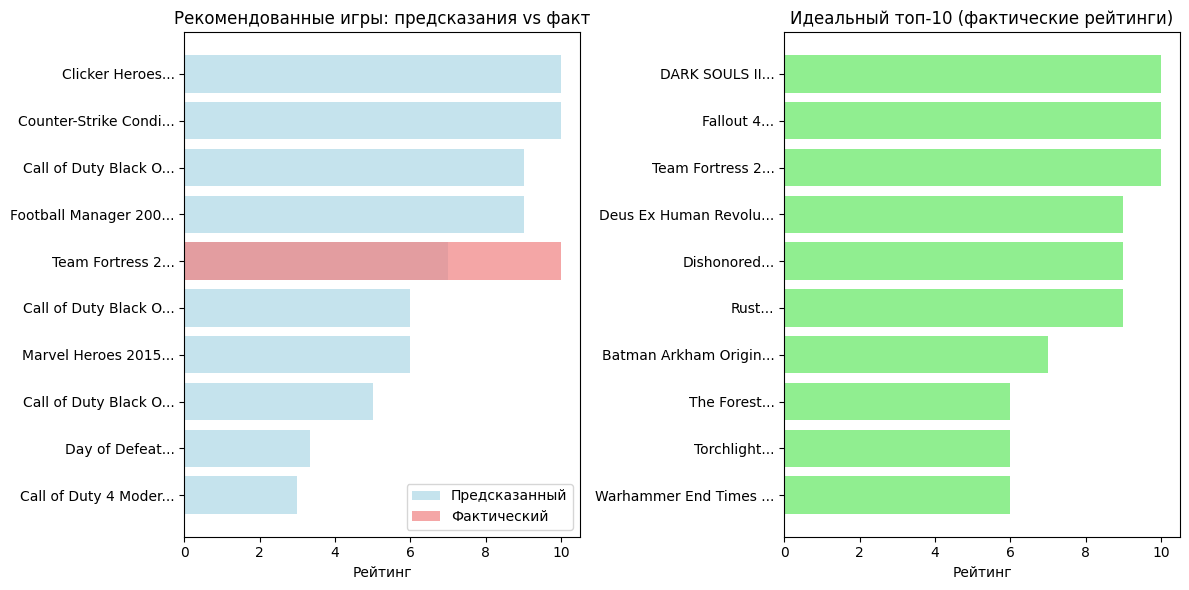

In [83]:
def analyze_ranking_quality(train_matrix, test_matrix, best_measure):
    """Анализ качества ранжирования рекомендаций"""
    user_id = test_matrix[(test_matrix > 0).sum(axis=1) >= 5].index[0]

    # Получаем предсказания
    predicted_ratings = predict_ratings_with_train(user_id, train_matrix, best_measure)
    predicted_series = pd.Series(predicted_ratings, index=train_matrix.columns)
    actual_series = test_matrix.loc[user_id]

    # Топ-10 предсказанных игр
    top_10_predicted = predicted_series.nlargest(10)

    # Фактические рейтинги для этих игр
    actual_for_predicted = actual_series[top_10_predicted.index]

    # Идеальный топ (по фактическим рейтингам)
    ideal_top = actual_series.nlargest(10)

    print(f"Анализ ранжирования для пользователя {user_id} (лучшая мера: {best_measure}):")
    print("\nТоп-10 рекомендованных игр vs Фактические рейтинги:")
    recommendation_analysis = pd.DataFrame({
        'Рекомендованная игра': top_10_predicted.index,
        'Предсказанный рейтинг': top_10_predicted.values,
        'Фактический рейтинг': actual_for_predicted.values
    })
    print(recommendation_analysis)

    print(f"\nИдеальный топ-10 (по фактическим рейтингам):")
    print(ideal_top)

    # Визуализация сравнения
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.barh(range(len(top_10_predicted)), top_10_predicted.values, color='lightblue', alpha=0.7, label='Предсказанный')
    plt.barh(range(len(actual_for_predicted)), actual_for_predicted.values, color='lightcoral', alpha=0.7, label='Фактический')
    plt.yticks(range(len(top_10_predicted)), [game[:20] + '...' for game in top_10_predicted.index])
    plt.xlabel('Рейтинг')
    plt.title('Рекомендованные игры: предсказания vs факт')
    plt.legend()
    plt.gca().invert_yaxis()

    plt.subplot(1, 2, 2)
    plt.barh(range(len(ideal_top)), ideal_top.values, color='lightgreen')
    plt.yticks(range(len(ideal_top)), [game[:20] + '...' for game in ideal_top.index])
    plt.xlabel('Рейтинг')
    plt.title('Идеальный топ-10 (фактические рейтинги)')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

# Определяем лучшую меру по MAP@10
best_measure = max(quality_results.items(), key=lambda x: x[1]['MAP@10'])[0]
analyze_ranking_quality(train_matrix, test_matrix, best_measure)